Here is how you can load the datasets with S3
1. In Config file: LOAD_FROM_S3=True
2. Enter you SSP Cloud secrets in a .env file (see READme)

In [5]:
#Imports
import s3fs
import pandas as pd
import logging
logging.basicConfig(level=logging.INFO)  #to be able to see the logging info+warnings(to only see warnings: logging.DEBUG)

from src.data_processing.data_load import data_loading
from src.data_processing.data_processing import DataProcessor


In [6]:
#To load data the from the different files directly
df_portefeuille, df_consommations, df_reclamations, df_interactions, df_impayes= data_loading("training")

In [7]:
#To load and process the data of a specific set (training, validation, evaluation) without normalisation of numerical values
processor = DataProcessor(mode="training")
df = processor.run(optional_normalisation=False)

INFO:src.data_processing.data_processing:Dropped columns from dataset: ['client_structure_familiale', 'client_nom_banque', 'client_nps_verbatim_n', 'client_nps_verbatim_n_moins1', 'impaye_nb_actions', 'impaye_montant_total', 'impaye_duree_max_action_jours', 'impaye_action_1er_impaye', 'impaye_action_1ere_lettre_relance', 'impaye_action_2eme_impaye', 'impaye_action_annonce_contentieux', 'impaye_action_en_recouvrement', 'impaye_action_mise_en_demeure', 'impaye_action_suspension_garanties', 'interaction_historique_mail']
INFO:src.data_processing.data_processing:Encoded with one-hot encoding: ['client_mode_paiement', 'client_frequence_paiement', 'courtier_reseau_courtage', 'courtier_segmentation_interne', 'courtier_type_commission', 'recla_canal_entrant_principale', 'recla_canal_entrant_secondaire']
INFO:src.data_processing.data_processing:Encoded with target encoding: ['client_ro_souscripteur', 'client_produit', 'client_garantie_base', 'client_garantie_base_plus_options', 'client_millesim

In [8]:
#Same but with normalisation of numerical values
processor = DataProcessor(mode="training")
df_norm = processor.run(optional_normalisation=True)

INFO:src.data_processing.data_processing:Dropped columns from dataset: ['client_structure_familiale', 'client_nom_banque', 'client_nps_verbatim_n', 'client_nps_verbatim_n_moins1', 'impaye_nb_actions', 'impaye_montant_total', 'impaye_duree_max_action_jours', 'impaye_action_1er_impaye', 'impaye_action_1ere_lettre_relance', 'impaye_action_2eme_impaye', 'impaye_action_annonce_contentieux', 'impaye_action_en_recouvrement', 'impaye_action_mise_en_demeure', 'impaye_action_suspension_garanties', 'interaction_historique_mail']
INFO:src.data_processing.data_processing:Encoded with one-hot encoding: ['client_mode_paiement', 'client_frequence_paiement', 'courtier_reseau_courtage', 'courtier_segmentation_interne', 'courtier_type_commission', 'recla_canal_entrant_principale', 'recla_canal_entrant_secondaire']
INFO:src.data_processing.data_processing:Encoded with target encoding: ['client_ro_souscripteur', 'client_produit', 'client_garantie_base', 'client_garantie_base_plus_options', 'client_millesim

In [9]:
df_norm #now for example, age is normalised (better to be processed by a linear model OR other specific models)

,client_code,client_age_souscripteur,client_ro_souscripteur,client_code_postal,client_departement,client_a_conjoint,client_nb_enfants,client_nb_assures_contrat,client_produit,client_garantie_base,...,courtier_segmentation_interne_Alptis,courtier_segmentation_interne_CMA,courtier_segmentation_interne_Opportuniste,courtier_segmentation_interne_Petit Producteur,courtier_segmentation_interne_Potentiel,courtier_segmentation_interne_VADISTE,courtier_segmentation_interne_VIP,courtier_type_commission_lineaire,courtier_type_commission_precompte,courtier_type_commission_precompte_majore
0,-3.898519,2.040562,0.558597,0.447000,0.454435,0.0,0.0,-0.595937,-1.366055,-1.299895,...,1,0,0,0,0,0,0,0,1,0
1,-3.898429,1.919114,0.558597,-1.068101,-1.064775,0.0,0.0,-0.595937,-1.366055,-1.299120,...,1,0,0,0,0,0,0,0,1,0
2,-3.898341,1.494049,-1.844826,0.470326,0.454435,1.0,0.0,0.706991,-1.366055,-1.299895,...,1,0,0,0,0,0,0,0,1,0
3,-3.898259,1.919114,-1.844826,0.443572,0.454435,0.0,0.0,-0.595937,-1.366055,-1.299120,...,1,0,0,0,0,0,0,0,1,0
4,-3.898230,1.615496,-1.844826,0.447000,0.454435,1.0,0.0,0.706991,-1.366055,-1.299120,...,1,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
132571,0.950031,-1.663582,0.558597,0.625123,0.631087,0.0,0.0,-0.595937,-1.223350,-1.120666,...,0,1,0,0,0,0,0,0,1,0
132572,0.950044,-0.024043,0.558597,-1.378650,-1.382749,0.0,0.0,-0.595937,-1.488218,-1.443664,...,1,0,0,0,0,0,0,0,1,0
132573,0.950125,-2.331542,0.558597,0.627244,0.631087,0.0,0.0,-0.595937,-1.223350,-1.295253,...,0,0,0,0,0,0,1,1,0,0
132574,0.950480,-2.513713,0.558597,1.440634,1.443687,0.0,0.0,-0.595937,-0.795205,-0.697177,...,0,0,0,0,0,0,0,1,0,0


In [10]:
import Config
print(Config.DATASET_MAPPING["validation"])

{'consommations': 'validation_consommations_2024_11.csv', 'impayes': 'validation_impayes_2024_11.csv', 'interactions': 'validation_interactions_2024_11.csv', 'portefeuille': 'validation_portefeuille_2024_11.csv', 'reclamations': 'validation_reclamations_2024_11.csv'}


In [11]:
import importlib
import Config

importlib.reload(Config)

print(Config.DATASET_MAPPING["validation"])

{'consommations': 'validation_consommations_2024_11.csv', 'impayes': 'validation_impayes_2024_11.csv', 'interactions': 'validation_interactions_2024_11.csv', 'portefeuille': 'validation_portefeuille_2024_11.csv', 'reclamations': 'validation_reclamations_2024_11.csv'}


In [12]:
from src.data_processing.data_processing import DataProcessor

train_processor = DataProcessor(mode="training")
df_train = train_processor.run()

val_processor = DataProcessor(mode="validation")
df_val = val_processor.run()

print("train:", df_train.shape)
print("val:", df_val.shape)

INFO:src.data_processing.data_processing:Dropped columns from dataset: ['client_structure_familiale', 'client_nom_banque', 'client_nps_verbatim_n', 'client_nps_verbatim_n_moins1', 'impaye_nb_actions', 'impaye_montant_total', 'impaye_duree_max_action_jours', 'impaye_action_1er_impaye', 'impaye_action_1ere_lettre_relance', 'impaye_action_2eme_impaye', 'impaye_action_annonce_contentieux', 'impaye_action_en_recouvrement', 'impaye_action_mise_en_demeure', 'impaye_action_suspension_garanties', 'interaction_historique_mail']
INFO:src.data_processing.data_processing:Encoded with one-hot encoding: ['client_mode_paiement', 'client_frequence_paiement', 'courtier_reseau_courtage', 'courtier_segmentation_interne', 'courtier_type_commission', 'recla_canal_entrant_principale', 'recla_canal_entrant_secondaire']
INFO:src.data_processing.data_processing:Encoded with target encoding: ['client_ro_souscripteur', 'client_produit', 'client_garantie_base', 'client_garantie_base_plus_options', 'client_millesim

train: (132576, 107)
val: (38449, 105)


In [13]:
from Config import TARGET_COLUMN

X_train = df_train.drop(columns=[TARGET_COLUMN, "client_code"])
y_train = df_train[TARGET_COLUMN]

X_val = df_val.drop(columns=[TARGET_COLUMN, "client_code"])
y_val = df_val[TARGET_COLUMN]

In [14]:
missing_in_val = sorted(set(X_train.columns) - set(X_val.columns))
extra_in_val = sorted(set(X_val.columns) - set(X_train.columns))

print("Colonnes manquantes dans val :", missing_in_val)
print("Colonnes en plus dans val :", extra_in_val)
print("Nb manquantes :", len(missing_in_val))
print("Nb en plus :", len(extra_in_val))

Colonnes manquantes dans val : ['courtier_changement_dans_les_12_mois', 'courtier_segmentation_interne_Potentiel', 'recla_initiateur_client', 'recla_latest_jours', 'recla_nombre']
Colonnes en plus dans val : ['client_nps_note_reco_n', 'courtier_segmentation_interne_Filiale', 'courtier_segmentation_interne_Groupements']
Nb manquantes : 5
Nb en plus : 3


In [15]:
from Config import TARGET_COLUMN

X_train = df_train.drop(columns=[TARGET_COLUMN, "client_code"])
y_train = df_train[TARGET_COLUMN]

X_val = df_val.drop(columns=[TARGET_COLUMN, "client_code"])
y_val = df_val[TARGET_COLUMN]

# Aligner val sur train
X_val = X_val.reindex(columns=X_train.columns, fill_value=0)

print(X_train.shape)
print(X_val.shape)
print(list(X_train.columns) == list(X_val.columns))

(132576, 105)
(38449, 105)
True


In [16]:
y_train.value_counts(normalize=True)

target_resiliation_6mois
0    0.891006
1    0.108994
Name: proportion, dtype: float64

In [17]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

# calcul du ratio
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

model_xgb = XGBClassifier(
    n_estimators=800,
    max_depth=5,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    reg_alpha=0.1,
    reg_lambda=1,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
)

model_xgb.fit(X_train, y_train)

proba_xgb = model_xgb.predict_proba(X_val)[:, 1]
score_xgb = roc_auc_score(y_val, proba_xgb)

print(" ROC-AUC XGBoost:", score_xgb)

 ROC-AUC XGBoost: 0.7954171704105132


In [18]:
import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.05, 0.6, 0.01)

rows = []

for t in thresholds:
    preds = (proba_xgb >= t).astype(int)
    
    rows.append({
        "threshold": t,
        "recall": recall_score(y_val, preds),
        "precision": precision_score(y_val, preds),
        "f1": f1_score(y_val, preds)
    })

df_thresh = pd.DataFrame(rows)

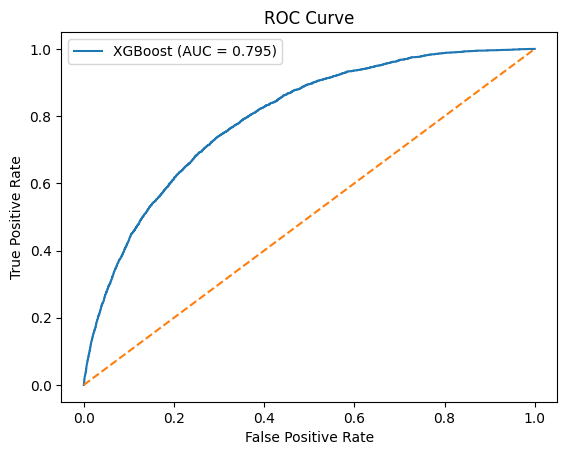

In [19]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_val, proba_xgb)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"XGBoost (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")  # baseline random
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [20]:
import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.05, 0.6, 0.01)

rows = []

for t in thresholds:
    preds = (proba_xgb >= t).astype(int)
    
    rows.append({
        "threshold": t,
        "recall": recall_score(y_val, preds),
        "precision": precision_score(y_val, preds),
        "f1": f1_score(y_val, preds)
    })

df_thresh = pd.DataFrame(rows)

In [21]:
df_good = df_thresh[df_thresh["recall"] >= 0.70]

df_good = df_good.sort_values("precision", ascending=False)

df_good.head(10)

,threshold,recall,precision,f1
41,0.46,0.708462,0.227895,0.344858
40,0.45,0.720513,0.224083,0.341849
39,0.44,0.734359,0.220630,0.339316
38,0.43,0.745641,0.216128,0.335120
37,0.42,0.754872,0.212165,0.331233
36,0.41,0.766923,0.208301,0.327619
35,0.40,0.777179,0.204273,0.323514
34,0.39,0.792051,0.200950,0.320569
33,0.38,0.803590,0.197467,0.317030
32,0.37,0.814103,0.193834,0.313116


In [22]:
best_t = df_good.iloc[0]["threshold"]

print("Chosen threshold:", best_t)

Chosen threshold: 0.4600000000000001


In [23]:
df_thresh.sort_values("recall", ascending=False).head(10)

,threshold,recall,precision,f1
0,0.05,0.996667,0.108533,0.195750
1,0.06,0.996410,0.109252,0.196914
2,0.07,0.996154,0.110216,0.198473
3,0.08,0.995897,0.111321,0.200258
4,0.09,0.995128,0.112630,0.202357
5,0.10,0.994615,0.114122,0.204751
6,0.11,0.993590,0.115603,0.207108
7,0.12,0.992051,0.117395,0.209947
8,0.13,0.990000,0.119414,0.213121
9,0.14,0.988718,0.121817,0.216909


In [24]:
df_thresh[(df_thresh["threshold"] >= 0.2) & (df_thresh["threshold"] <= 0.5)]

,threshold,recall,precision,f1
15,0.20,0.961795,0.136624,0.239260
16,0.21,0.954615,0.139287,0.243103
17,0.22,0.948974,0.142013,0.247055
18,0.23,0.941795,0.144897,0.251154
19,0.24,0.937179,0.148324,0.256114
20,0.25,0.933333,0.152206,0.261729
21,0.26,0.924103,0.155211,0.265782
22,0.27,0.915385,0.158498,0.270209
23,0.28,0.908205,0.162336,0.275438
24,0.29,0.900769,0.166036,0.280389


###Le choix du seuil a été fait en fonction du recall, car dans notre cas métier, rater un client à risque de churn est plus coûteux que cibler un client qui n’aurait pas churné.
Nous avons donc ajusté le seuil pour maximiser la détection des churn, tout en gardant un niveau de précision acceptable.

In [25]:
from xgboost import XGBClassifier

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

model_xgb = XGBClassifier(
    n_estimators=800, # nombre d'itteration
    max_depth=5,       # Profondeur d'arbre
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight, # gere l'équilibre de classe
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss" # metric d'évaluation
)

model_xgb.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [26]:
THRESHOLD = 0.30

In [27]:
proba_val = model_xgb.predict_proba(X_val)[:, 1]

y_pred_val = (proba_val >= THRESHOLD).astype(int)

In [28]:
from sklearn.metrics import classification_report, roc_auc_score

print("ROC-AUC:", roc_auc_score(y_val, proba_val))
print(classification_report(y_val, y_pred_val))

ROC-AUC: 0.7961612009995466
              precision    recall  f1-score   support

           0       0.98      0.51      0.67     34549
           1       0.17      0.89      0.29      3900

    accuracy                           0.55     38449
   macro avg       0.57      0.70      0.48     38449
weighted avg       0.89      0.55      0.63     38449



###Le modèle est orienté recall : il détecte la grande majorité des churn (89%), mais au prix d’un grand nombre de faux positifs.
Cela signifie qu’on privilégie la détection des clients à risque plutôt que la précision des campagnes.

In [29]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_val, y_pred_val)
print(cm)

[[17569 16980]
 [  423  3477]]


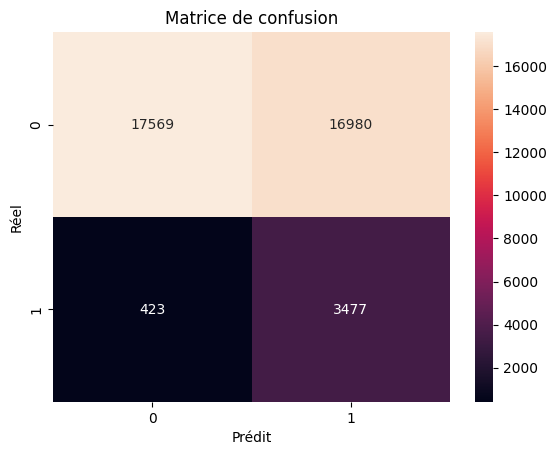

In [30]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Calcul matrice
cm = confusion_matrix(y_val, y_pred_val)

# Plot
plt.figure()
sns.heatmap(cm, annot=True, fmt="d")

plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.title("Matrice de confusion")

plt.show()

In [31]:
import pandas as pd
import numpy as np

def get_feature_importance(pipeline, X):
    # récupérer modèle
    model = pipeline.named_steps["model"]
    preprocessor = pipeline.named_steps["preprocessor"]

    # récupérer noms des features après preprocessing
    feature_names = preprocessor.get_feature_names_out()

    # importance selon modèle
    if hasattr(model, "feature_importances_"):
        importances = model.feature_importances_
    elif hasattr(model, "coef_"):
        importances = np.abs(model.coef_[0])
    else:
        raise ValueError("Modèle non supporté")

    # dataframe
    df_importance = pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    }).sort_values(by="importance", ascending=False)

    return df_importance